In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("Trade Journal Analyser ready")

Trade Journal Analyser ready


In [2]:
# Trade journal structure
# You'll enter your real trades here
# For now we build the framework with sample data
# Replace with your actual trades

trades_data = [
    # date, pair, direction, entry, sl, tp, exit_price, outcome
    # outcome: 'WIN' or 'LOSS' or 'BE' (breakeven)
    # Replace these with your real trades
    {"date": "2024-01-02", "pair": "XAUUSD", "direction": "LONG",
     "entry": 2063.5, "sl": 2055.0, "tp": 2080.0,
     "exit_price": 2078.0, "outcome": "WIN", "session": "London",
     "setup": "SMC", "notes": "BOS + OB retest"},

    {"date": "2024-01-03", "pair": "XAUUSD", "direction": "SHORT",
     "entry": 2082.0, "sl": 2090.0, "tp": 2062.0,
     "exit_price": 2090.0, "outcome": "LOSS", "session": "NY",
     "setup": "SMC", "notes": "Stop hunted"},

    {"date": "2024-01-04", "pair": "GBPUSD", "direction": "LONG",
     "entry": 1.2715, "sl": 1.2685, "tp": 1.2775,
     "exit_price": 1.2775, "outcome": "WIN", "session": "London",
     "setup": "Lipschutz", "notes": "HTF bias confirmed"},

    {"date": "2024-01-08", "pair": "XAUUSD", "direction": "LONG",
     "entry": 2030.0, "sl": 2020.0, "tp": 2055.0,
     "exit_price": 2020.0, "outcome": "LOSS", "session": "Asian",
     "setup": "SMC", "notes": "Asian range break failed"},

    {"date": "2024-01-09", "pair": "GBPJPY", "direction": "SHORT",
     "entry": 183.50, "sl": 184.20, "tp": 182.10,
     "exit_price": 182.10, "outcome": "WIN", "session": "London",
     "setup": "SMC", "notes": "Supply zone rejection"},
]

# Convert to DataFrame
df = pd.DataFrame(trades_data)
df['date'] = pd.to_datetime(df['date'])

# Calculate R-multiples automatically
df['risk_pips']   = abs(df['entry'] - df['sl'])
df['reward_pips'] = abs(df['tp']    - df['entry'])
df['rr_ratio']    = df['reward_pips'] / df['risk_pips']

# Actual R achieved
df['actual_r'] = np.where(
    df['outcome'] == 'WIN',
    abs(df['exit_price'] - df['entry']) / df['risk_pips'],
    np.where(
        df['outcome'] == 'LOSS',
        -abs(df['exit_price'] - df['entry']) / df['risk_pips'],
        0  # breakeven
    )
)

print("Sample trade journal loaded")
print(f"Total trades: {len(df)}")
print(f"\n{df[['date','pair','direction','rr_ratio','actual_r','outcome']].to_string(index=False)}")

Sample trade journal loaded
Total trades: 5

      date   pair direction  rr_ratio  actual_r outcome
2024-01-02 XAUUSD      LONG  1.941176  1.705882     WIN
2024-01-03 XAUUSD     SHORT  2.500000 -1.000000    LOSS
2024-01-04 GBPUSD      LONG  2.000000  2.000000     WIN
2024-01-08 XAUUSD      LONG  2.500000 -1.000000    LOSS
2024-01-09 GBPJPY     SHORT  2.000000  2.000000     WIN


In [3]:
def analyse_journal(df):
    """
    Complete trade journal analysis.
    Prints all key metrics a quant trader needs.
    """
    total    = len(df)
    wins     = (df['outcome']=='WIN').sum()
    losses   = (df['outcome']=='LOSS').sum()
    be       = (df['outcome']=='BE').sum()
    win_rate = wins / total

    avg_win  = df[df['outcome']=='WIN']['actual_r'].mean()
    avg_loss = df[df['outcome']=='LOSS']['actual_r'].mean()
    avg_rr   = df['rr_ratio'].mean()
    expectancy = (win_rate * avg_win) + \
                 ((1-win_rate) * abs(avg_loss))

    # Cumulative R curve
    df_sorted = df.sort_values('date').copy()
    df_sorted['cumulative_r'] = df_sorted['actual_r'].cumsum()

    # Max drawdown in R
    cum_r = df_sorted['cumulative_r']
    dd_r  = (cum_r - cum_r.cummax()).min()

    print(f"\n{'='*55}")
    print(f"  TRADE JOURNAL ANALYSIS")
    print(f"{'='*55}")
    print(f"  Total trades     : {total}")
    print(f"  Wins/Losses/BE   : {wins}/{losses}/{be}")
    print(f"  Win rate         : {win_rate:.1%}")
    print(f"  Avg planned RR   : {avg_rr:.2f}")
    print(f"  Avg win (R)      : +{avg_win:.2f}R")
    print(f"  Avg loss (R)     : {avg_loss:.2f}R")
    print(f"  Expectancy       : {expectancy:.3f}R per trade")
    print(f"  Max DD (R)       : {dd_r:.2f}R")
    print(f"  Total R earned   : {df_sorted['actual_r'].sum():.2f}R")
    print(f"{'='*55}")

    # Breakdown by pair
    print(f"\n  BY PAIR:")
    print(f"  {'-'*45}")
    for pair in df['pair'].unique():
        p = df[df['pair']==pair]
        wr = (p['outcome']=='WIN').mean()
        er = p['actual_r'].mean()
        print(f"  {pair:<10} Trades:{len(p):>3}  "
              f"WR:{wr:.0%}  Avg R:{er:>+.2f}")

    # Breakdown by session
    if 'session' in df.columns:
        print(f"\n  BY SESSION:")
        print(f"  {'-'*45}")
        for sess in df['session'].unique():
            s = df[df['session']==sess]
            wr = (s['outcome']=='WIN').mean()
            er = s['actual_r'].mean()
            print(f"  {sess:<10} Trades:{len(s):>3}  "
                  f"WR:{wr:.0%}  Avg R:{er:>+.2f}")

    # Breakdown by setup
    if 'setup' in df.columns:
        print(f"\n  BY SETUP:")
        print(f"  {'-'*45}")
        for setup in df['setup'].unique():
            s = df[df['setup']==setup]
            wr = (s['outcome']=='WIN').mean()
            er = s['actual_r'].mean()
            print(f"  {setup:<12} Trades:{len(s):>3}  "
                  f"WR:{wr:.0%}  Avg R:{er:>+.2f}")

    return df_sorted

df_analysed = analyse_journal(df)



  TRADE JOURNAL ANALYSIS
  Total trades     : 5
  Wins/Losses/BE   : 3/2/0
  Win rate         : 60.0%
  Avg planned RR   : 2.19
  Avg win (R)      : +1.90R
  Avg loss (R)     : -1.00R
  Expectancy       : 1.541R per trade
  Max DD (R)       : -1.00R
  Total R earned   : 3.71R

  BY PAIR:
  ---------------------------------------------
  XAUUSD     Trades:  3  WR:33%  Avg R:-0.10
  GBPUSD     Trades:  1  WR:100%  Avg R:+2.00
  GBPJPY     Trades:  1  WR:100%  Avg R:+2.00

  BY SESSION:
  ---------------------------------------------
  London     Trades:  3  WR:100%  Avg R:+1.90
  NY         Trades:  1  WR:0%  Avg R:-1.00
  Asian      Trades:  1  WR:0%  Avg R:-1.00

  BY SETUP:
  ---------------------------------------------
  SMC          Trades:  4  WR:50%  Avg R:+0.43
  Lipschutz    Trades:  1  WR:100%  Avg R:+2.00


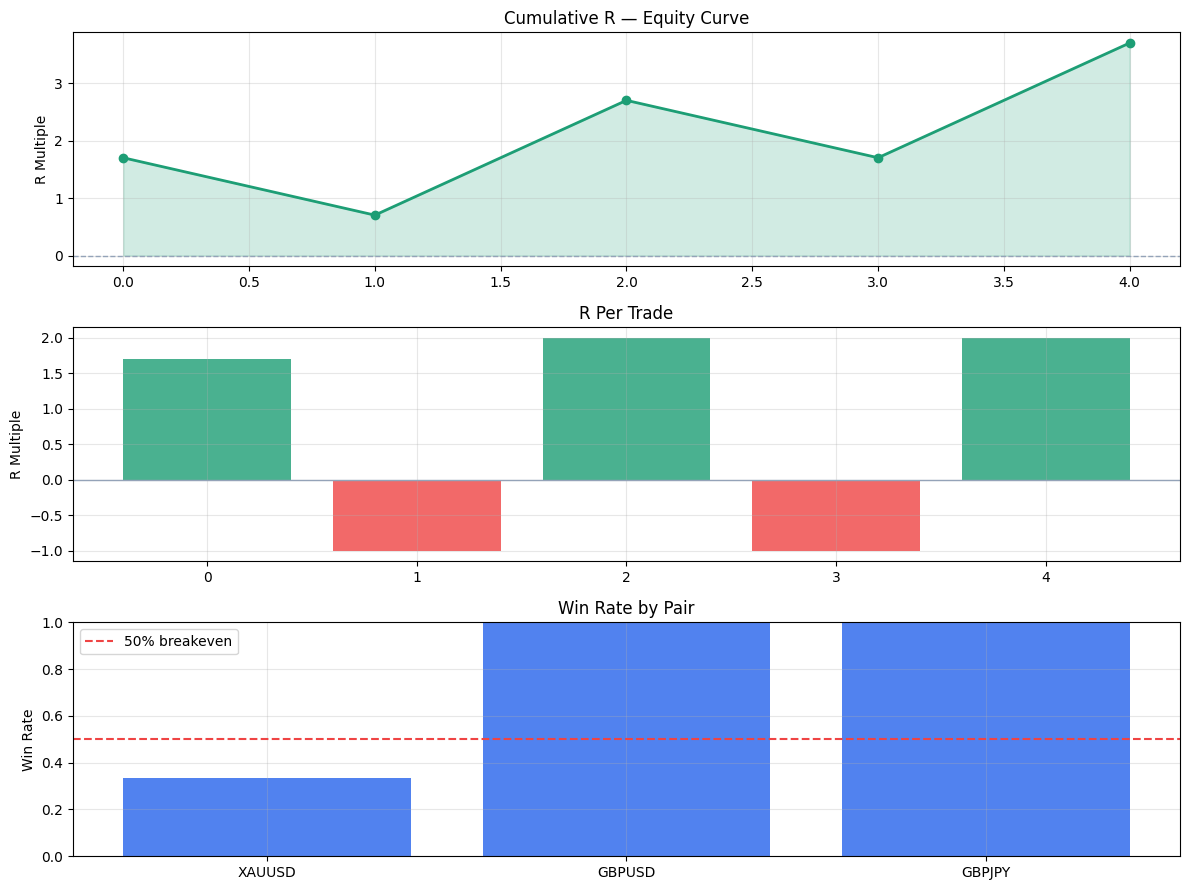

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9))

# Panel 1: Cumulative R curve
ax1.plot(range(len(df_analysed)),
         df_analysed['cumulative_r'],
         color='#1D9E75', lw=2, marker='o', markersize=6)
ax1.axhline(0, color='#94a3b8', lw=1, linestyle='--')
ax1.fill_between(range(len(df_analysed)),
                  df_analysed['cumulative_r'], 0,
                  where=(df_analysed['cumulative_r']>=0),
                  alpha=0.2, color='#1D9E75')
ax1.fill_between(range(len(df_analysed)),
                  df_analysed['cumulative_r'], 0,
                  where=(df_analysed['cumulative_r']<0),
                  alpha=0.2, color='#ef4444')
ax1.set_title('Cumulative R — Equity Curve')
ax1.set_ylabel('R Multiple')
ax1.grid(True, alpha=0.3)

# Panel 2: R per trade bar chart
colors_bar = ['#1D9E75' if r > 0 else '#ef4444'
               for r in df_analysed['actual_r']]
ax2.bar(range(len(df_analysed)),
        df_analysed['actual_r'],
        color=colors_bar, alpha=0.8)
ax2.axhline(0, color='#94a3b8', lw=1)
ax2.set_title('R Per Trade')
ax2.set_ylabel('R Multiple')
ax2.grid(True, alpha=0.3)

# Panel 3: Win rate by pair
pairs    = df['pair'].unique()
wr_pairs = [((df[df['pair']==p]['outcome']=='WIN').mean())
             for p in pairs]
ax3.bar(pairs, wr_pairs, color='#2563eb', alpha=0.8)
ax3.axhline(0.5, color='#ef4444', lw=1.5,
            linestyle='--', label='50% breakeven')
ax3.set_title('Win Rate by Pair')
ax3.set_ylabel('Win Rate')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
def add_trade(df, date, pair, direction, entry, sl, tp,
              exit_price, outcome, session, setup, notes=""):
    """
    Add a single trade to the journal.
    Call this after every trade you take.

    Parameters:
    -----------
    date       : "YYYY-MM-DD"
    pair       : "XAUUSD", "GBPUSD", "GBPJPY"
    direction  : "LONG" or "SHORT"
    entry      : entry price
    sl         : stop loss price
    tp         : take profit price
    exit_price : actual exit price
    outcome    : "WIN", "LOSS", or "BE"
    session    : "London", "NY", "Asian"
    setup      : "SMC", "Lipschutz", "Combined"
    notes      : any observations about the trade
    """
    risk_pips   = abs(entry - sl)
    reward_pips = abs(tp - entry)
    rr_ratio    = reward_pips / risk_pips

    if outcome == 'WIN':
        actual_r = abs(exit_price - entry) / risk_pips
    elif outcome == 'LOSS':
        actual_r = -abs(exit_price - entry) / risk_pips
    else:
        actual_r = 0

    new_trade = pd.DataFrame([{
        "date"       : pd.to_datetime(date),
        "pair"       : pair,
        "direction"  : direction,
        "entry"      : entry,
        "sl"         : sl,
        "tp"         : tp,
        "exit_price" : exit_price,
        "outcome"    : outcome,
        "session"    : session,
        "setup"      : setup,
        "notes"      : notes,
        "risk_pips"  : risk_pips,
        "reward_pips": reward_pips,
        "rr_ratio"   : rr_ratio,
        "actual_r"   : actual_r
    }])

    df = pd.concat([df, new_trade], ignore_index=True)
    print(f"Trade added: {direction} {pair} {outcome} "
          f"({actual_r:+.2f}R)")
    return df

# ── ENTER YOUR REAL TRADES BELOW ─────────────────────────
# Replace the sample data — call add_trade() for each
# real trade you've taken recently

# Example — replace with your actual trades:
# df = add_trade(df, "2024-01-15", "XAUUSD", "LONG",
#                2015.0, 2005.0, 2040.0, 2038.0,
#                "WIN", "London", "SMC",
#                "BOS confirmed H1, OB retest entry")

# For now run analysis on sample data
print("Template ready — enter your real trades above")
print("Then re-run analyse_journal(df) to see your stats")
print(f"\nCurrent journal: {len(df)} trades")

Template ready — enter your real trades above
Then re-run analyse_journal(df) to see your stats

Current journal: 5 trades


In [6]:
# Clear sample data and start with real trades
df = pd.DataFrame(columns=['date','pair','direction','entry',
                             'sl','tp','exit_price','outcome',
                             'session','setup','notes',
                             'risk_pips','reward_pips',
                             'rr_ratio','actual_r'])

df = add_trade(df, "2026-07-02", "XAUUSD", "LONG",
               4073.17, 4046.97, 4131.70, 4182.47, "WIN",  "Tokyo",    "SMC", "")
df = add_trade(df, "2026-07-01", "XAUUSD", "SHORT",
               4013.02, 4035.51, 3960.54, 3960.54, "WIN",  "NY",       "SMC", "")
df = add_trade(df, "2026-06-29", "XAUUSD", "SHORT",
               4031.33, 4074.75, 3972.48, 3972.48, "WIN",  "London",   "SMC", "")
df = add_trade(df, "2026-06-26", "XAUUSD", "LONG",
               4090.06, 4045.21, 4147.94, 4045.21, "LOSS", "NY",       "SMC", "")
df = add_trade(df, "2026-06-26", "XAUUSD", "SHORT",
               4004.19, 4028.52, 3938.55, 4028.52, "LOSS", "Tokyo",    "SMC", "")
df = add_trade(df, "2026-06-24", "XAUUSD", "SHORT",
               4055.45, 4085.88, 3978.71, 3978.71, "WIN",  "London",   "SMC", "")
df = add_trade(df, "2026-06-23", "XAUUSD", "SHORT",
               4104.02, 4132.50, 4033.45, 4018.09, "WIN",  "NY",       "SMC", "")
df = add_trade(df, "2026-06-23", "XAUUSD", "SHORT",
               4160.98, 4216.54, 4087.90, 4087.90, "WIN",  "Tokyo",    "SMC", "")
df = add_trade(df, "2026-06-18", "XAUUSD", "SHORT",
               4266.46, 4316.42, 4171.98, 4171.98, "WIN",  "London",   "SMC", "")
df = add_trade(df, "2026-06-16", "XAUUSD", "LONG",
               4346.56, 4316.71, 4409.61, 4316.71, "LOSS", "London",   "SMC", "")
df = add_trade(df, "2026-06-15", "XAUUSD", "LONG",
               4285.53, 4207.56, 4400.49, 4207.56, "LOSS", "Sydney",   "SMC", "")
df = add_trade(df, "2026-06-10", "XAUUSD", "SHORT",
               4146.80, 4198.67, 4047.17, 4047.17, "WIN",  "London",   "SMC", "")
df = add_trade(df, "2026-06-09", "XAUUSD", "SHORT",
               4300.25, 4353.60, 4220.56, 4220.56, "WIN",  "NY",       "SMC", "")
df = add_trade(df, "2026-06-09", "XAUUSD", "SHORT",
               4326.41, 4353.60, 4258.56, 4353.60, "LOSS", "London",   "SMC", "")
df = add_trade(df, "2026-06-05", "XAUUSD", "SHORT",
               4461.43, 4490.10, 4396.79, 4330.70, "WIN",  "Sydney",   "SMC", "")
df = add_trade(df, "2026-06-03", "XAUUSD", "SHORT",
               4438.73, 4465.61, 4368.90, 4465.61, "LOSS", "NY",       "SMC", "")

# Run the full analysis
df_analysed = analyse_journal(df)

Trade added: LONG XAUUSD WIN (+4.17R)
Trade added: SHORT XAUUSD WIN (+2.33R)
Trade added: SHORT XAUUSD WIN (+1.36R)
Trade added: LONG XAUUSD LOSS (-1.00R)
Trade added: SHORT XAUUSD LOSS (-1.00R)
Trade added: SHORT XAUUSD WIN (+2.52R)
Trade added: SHORT XAUUSD WIN (+3.02R)
Trade added: SHORT XAUUSD WIN (+1.32R)
Trade added: SHORT XAUUSD WIN (+1.89R)
Trade added: LONG XAUUSD LOSS (-1.00R)
Trade added: LONG XAUUSD LOSS (-1.00R)
Trade added: SHORT XAUUSD WIN (+1.92R)
Trade added: SHORT XAUUSD WIN (+1.49R)
Trade added: SHORT XAUUSD LOSS (-1.00R)
Trade added: SHORT XAUUSD WIN (+4.56R)
Trade added: SHORT XAUUSD LOSS (-1.00R)

  TRADE JOURNAL ANALYSIS
  Total trades     : 16
  Wins/Losses/BE   : 10/6/0
  Win rate         : 62.5%
  Avg planned RR   : 2.03
  Avg win (R)      : +2.46R
  Avg loss (R)     : -1.00R
  Expectancy       : 1.911R per trade
  Max DD (R)       : -2.00R
  Total R earned   : 18.58R

  BY PAIR:
  ---------------------------------------------
  XAUUSD     Trades: 16  WR:62%  

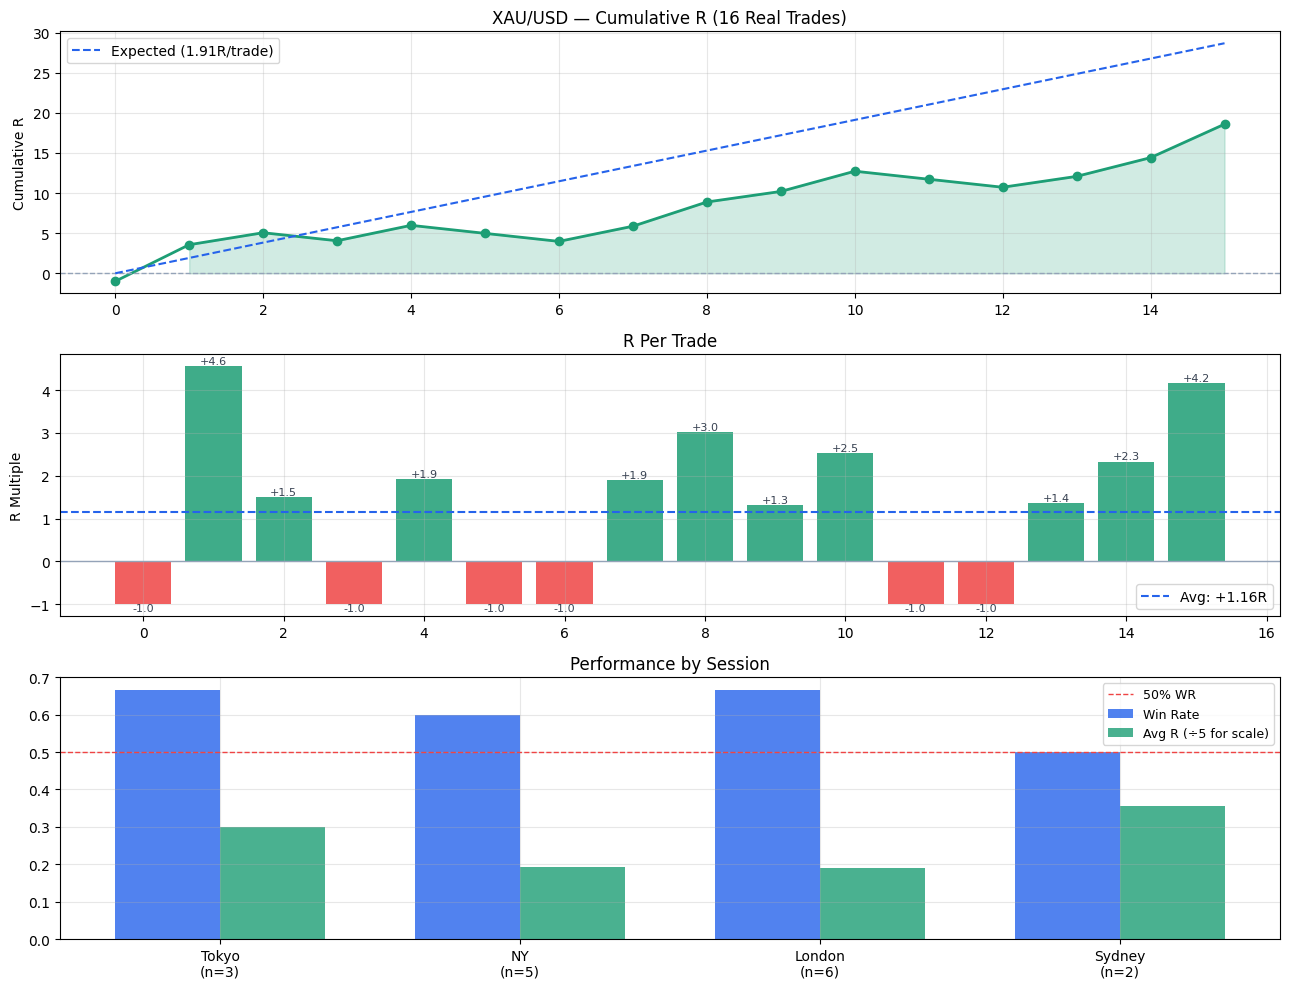

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 10))

df_sorted = df.sort_values('date').copy()
df_sorted['cumulative_r'] = df_sorted['actual_r'].astype(float).cumsum()
cum_r = df_sorted['cumulative_r'].astype(float).values
act_r = df_sorted['actual_r'].astype(float).values
x_idx = np.arange(len(df_sorted), dtype=float)

# Panel 1: Cumulative R
ax1.plot(x_idx, cum_r, color='#1D9E75', lw=2,
         marker='o', markersize=6)
ax1.axhline(0, color='#94a3b8', lw=1, linestyle='--')
ax1.fill_between(x_idx, cum_r, 0,
                  where=(cum_r >= 0),
                  alpha=0.2, color='#1D9E75')
ax1.plot(x_idx, 1.911 * x_idx, color='#2563eb',
         lw=1.5, linestyle='--',
         label='Expected (1.91R/trade)')
ax1.set_title('XAU/USD — Cumulative R (16 Real Trades)')
ax1.set_ylabel('Cumulative R')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Individual R bars
colors_bar = ['#1D9E75' if r > 0 else '#ef4444' for r in act_r]
bars = ax2.bar(x_idx, act_r, color=colors_bar, alpha=0.85)
ax2.axhline(0, color='#94a3b8', lw=1)
ax2.axhline(float(act_r.mean()), color='#2563eb', lw=1.5,
            linestyle='--',
            label=f"Avg: +{act_r.mean():.2f}R")
ax2.set_title('R Per Trade')
ax2.set_ylabel('R Multiple')
ax2.legend()
ax2.grid(True, alpha=0.3)
for bar, r in zip(bars, act_r):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05 if r > 0
             else bar.get_height() - 0.15,
             f'{r:+.1f}', ha='center',
             fontsize=8, color='#374151')

# Panel 3: Session performance
sessions   = df['session'].unique()
sess_wr    = [(df[df['session']==s]['outcome']=='WIN').mean()
               for s in sessions]
sess_avgr  = [float(df[df['session']==s]['actual_r'].astype(float).mean())
               for s in sessions]
sess_count = [len(df[df['session']==s]) for s in sessions]

x = np.arange(len(sessions))
w = 0.35
ax3.bar(x - w/2, sess_wr, w, color='#2563eb',
        alpha=0.8, label='Win Rate')
ax3.bar(x + w/2, [r/5 for r in sess_avgr], w,
        color='#1D9E75', alpha=0.8,
        label='Avg R (÷5 for scale)')
ax3.set_xticks(x)
ax3.set_xticklabels([f"{s}\n(n={c})"
                      for s, c in zip(sessions, sess_count)])
ax3.axhline(0.5, color='#ef4444', lw=1,
            linestyle='--', label='50% WR')
ax3.set_title('Performance by Session')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
import inspect

code = '''import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def add_trade(df, date, pair, direction, entry, sl, tp,
              exit_price, outcome, session, setup, notes=""):
    """
    Add a single trade to the journal.
    outcome: WIN, LOSS, or BE
    session: London, NY, Tokyo, Sydney
    setup  : SMC, Lipschutz, Combined
    """
    risk_pips   = abs(entry - sl)
    reward_pips = abs(tp - entry)
    rr_ratio    = reward_pips / risk_pips

    if outcome == "WIN":
        actual_r = abs(exit_price - entry) / risk_pips
    elif outcome == "LOSS":
        actual_r = -abs(exit_price - entry) / risk_pips
    else:
        actual_r = 0.0

    new_trade = pd.DataFrame([{
        "date"       : pd.to_datetime(date),
        "pair"       : pair,
        "direction"  : direction,
        "entry"      : entry,
        "sl"         : sl,
        "tp"         : tp,
        "exit_price" : exit_price,
        "outcome"    : outcome,
        "session"    : session,
        "setup"      : setup,
        "notes"      : notes,
        "risk_pips"  : risk_pips,
        "reward_pips": reward_pips,
        "rr_ratio"   : rr_ratio,
        "actual_r"   : float(actual_r)
    }])

    df = pd.concat([df, new_trade], ignore_index=True)
    print(f"  Added: {direction} {pair} {outcome} "
          f"({float(actual_r):+.2f}R)")
    return df


def analyse_journal(df):
    """Full trade journal analysis with breakdown by pair, session, setup."""
    total    = len(df)
    wins     = (df["outcome"]=="WIN").sum()
    losses   = (df["outcome"]=="LOSS").sum()
    win_rate = wins / total

    avg_win  = df[df["outcome"]=="WIN"]["actual_r"].astype(float).mean()
    avg_loss = df[df["outcome"]=="LOSS"]["actual_r"].astype(float).mean()
    exp      = (win_rate * avg_win) + ((1-win_rate) * abs(avg_loss))

    df_s = df.sort_values("date").copy()
    df_s["cumulative_r"] = df_s["actual_r"].astype(float).cumsum()
    dd_r = (df_s["cumulative_r"] - df_s["cumulative_r"].cummax()).min()

    print(f"\\n{\'=\'*55}")
    print(f"  TRADE JOURNAL ANALYSIS")
    print(f"{\'=\'*55}")
    print(f"  Total trades   : {total}")
    print(f"  Wins/Losses    : {wins}/{losses}")
    print(f"  Win rate       : {win_rate:.1%}")
    print(f"  Avg win (R)    : +{avg_win:.2f}R")
    print(f"  Avg loss (R)   : {avg_loss:.2f}R")
    print(f"  Expectancy     : {exp:.3f}R per trade")
    print(f"  Max DD (R)     : {dd_r:.2f}R")
    print(f"  Total R earned : {df_s[\'actual_r\'].astype(float).sum():.2f}R")
    print(f"{\'=\'*55}")

    for col in ["pair", "session", "setup"]:
        if col in df.columns:
            print(f"\\n  BY {col.upper()}:")
            for val in df[col].unique():
                sub = df[df[col]==val]
                wr  = (sub["outcome"]=="WIN").mean()
                er  = sub["actual_r"].astype(float).mean()
                print(f"  {val:<12} n:{len(sub):>3}  "
                      f"WR:{wr:.0%}  Avg R:{er:>+.2f}")

    return df_s
'''

with open("trade_journal_analyser.py", "w",
          encoding="utf-8") as f:
    f.write(code)

print("Saved to forex/trade_journal_analyser.py")

Saved to forex/trade_journal_analyser.py


In [9]:
# POSITION SIZER based on your real edge
# Using your actual stats: WR=62.5%, Avg Win=2.46R, Avg Loss=1.00R

win_rate = 0.625
avg_win  = 2.46
avg_loss = 1.00

# Kelly fraction
kelly = win_rate - ((1 - win_rate) / (avg_win / avg_loss))

print(f"{'='*50}")
print(f"  KELLY CALCULATION FROM REAL TRADES")
print(f"{'='*50}")
print(f"  Win rate       : {win_rate:.1%}")
print(f"  Avg win        : +{avg_win:.2f}R")
print(f"  Avg loss       : -{avg_loss:.2f}R")
print(f"  Full Kelly     : {kelly:.1%} of account per trade")
print(f"  Half Kelly     : {kelly/2:.1%} of account per trade")
print(f"  Quarter Kelly  : {kelly/4:.1%} of account per trade")
print(f"{'='*50}")
print(f"\n  Professional recommendation: Half Kelly")
print(f"  = risk {kelly/2:.1%} of account per trade")

  KELLY CALCULATION FROM REAL TRADES
  Win rate       : 62.5%
  Avg win        : +2.46R
  Avg loss       : -1.00R
  Full Kelly     : 47.3% of account per trade
  Half Kelly     : 23.6% of account per trade
  Quarter Kelly  : 11.8% of account per trade

  Professional recommendation: Half Kelly
  = risk 23.6% of account per trade


In [10]:
def position_sizer(account_balance, risk_pct,
                   entry, sl, pair="XAUUSD"):
    """
    Calculate position size for forex/gold trades.

    Parameters:
    -----------
    account_balance : total account in USD
    risk_pct        : % of account to risk (e.g. 0.01 = 1%)
    entry           : entry price
    sl              : stop loss price
    pair            : trading pair
    """
    risk_usd   = account_balance * risk_pct
    stop_pips  = abs(entry - sl)

    if pair == "XAUUSD":
        # Gold: 1 lot = 100 oz, pip value ≈ $1 per 0.01
        pip_value_per_lot = 100   # $100 per $1 move, 1 lot
        lots = risk_usd / (stop_pips * pip_value_per_lot)
    elif "JPY" in pair:
        # JPY pairs: pip = 0.01
        pip_value_per_lot = 1000
        lots = risk_usd / (stop_pips * pip_value_per_lot)
    else:
        # Major pairs: pip = 0.0001
        pip_value_per_lot = 10
        lots = risk_usd / (stop_pips * pip_value_per_lot / 0.0001)

    return {
        "risk_usd"  : risk_usd,
        "stop_pips" : stop_pips,
        "lots"      : round(lots, 2),
        "mini_lots" : round(lots * 10, 2),
        "micro_lots": round(lots * 100, 2)
    }

# Show position sizes at different risk levels
# Using your most recent trade as example
entry = 4073.17
sl    = 4046.97

print(f"\nPOSITION SIZER — XAUUSD")
print(f"Entry: {entry} | SL: {sl} | Stop: {abs(entry-sl):.2f} pips")
print(f"{'='*62}")
print(f"  {'Account':>10} {'Risk %':>8} {'Risk $':>8} "
      f"{'Lots':>8} {'Mini':>8} {'Micro':>8}")
print(f"  {'-'*57}")

for balance in [1000, 5000, 10000, 25000, 50000]:
    for risk_pct in [0.01, 0.02]:
        r = position_sizer(balance, risk_pct, entry, sl)
        print(f"  ${balance:>9,.0f} {risk_pct:>8.0%} "
              f"${r['risk_usd']:>7.0f} "
              f"{r['lots']:>8.2f} "
              f"{r['mini_lots']:>8.2f} "
              f"{r['micro_lots']:>8.2f}")

print(f"{'='*62}")
print(f"\nRecommendation for your current stats:")
print(f"  Risk 1-2% per trade maximum")
print(f"  Kelly says 23.6% but with only 16 trades")
print(f"  the estimate has wide uncertainty — stay conservative")
print(f"  Scale up only after 50+ trades confirm the edge")


POSITION SIZER — XAUUSD
Entry: 4073.17 | SL: 4046.97 | Stop: 26.20 pips
     Account   Risk %   Risk $     Lots     Mini    Micro
  ---------------------------------------------------------
  $    1,000       1% $     10     0.00     0.04     0.38
  $    1,000       2% $     20     0.01     0.08     0.76
  $    5,000       1% $     50     0.02     0.19     1.91
  $    5,000       2% $    100     0.04     0.38     3.82
  $   10,000       1% $    100     0.04     0.38     3.82
  $   10,000       2% $    200     0.08     0.76     7.63
  $   25,000       1% $    250     0.10     0.95     9.54
  $   25,000       2% $    500     0.19     1.91    19.08
  $   50,000       1% $    500     0.19     1.91    19.08
  $   50,000       2% $   1000     0.38     3.82    38.17

Recommendation for your current stats:
  Risk 1-2% per trade maximum
  Kelly says 23.6% but with only 16 trades
  the estimate has wide uncertainty — stay conservative
  Scale up only after 50+ trades confirm the edge


In [11]:
# YOUR PERSONAL TRADING PARAMETERS
# Account: $10,000 | Risk: 1% per trade

account  = 10000
risk_pct = 0.01   # start at 1%, move to 2% after 50 trades

print(f"{'='*55}")
print(f"  JUSTIN'S XAUUSD TRADING PARAMETERS")
print(f"  Account: ${account:,.0f} | Risk: {risk_pct:.0%} per trade")
print(f"{'='*55}")

# Show for different stop sizes you commonly use
stop_sizes = [15, 20, 26, 30, 35, 40, 50, 78]

print(f"\n  {'Stop (pips)':>12} {'Risk $':>8} {'Lots':>8} "
      f"{'Mini':>8} {'Micro':>8}")
print(f"  {'-'*50}")

for stop in stop_sizes:
    risk_usd = account * risk_pct
    lots     = risk_usd / (stop * 100)
    print(f"  {stop:>12} ${risk_usd:>7.0f} {lots:>8.3f} "
          f"{lots*10:>8.2f} {lots*100:>8.1f}")

print(f"\n{'='*55}")
print(f"  QUICK REFERENCE CARD")
print(f"{'='*55}")
print(f"  Account balance : $10,000")
print(f"  Max risk/trade  : $100 (1%)")
print(f"  Typical stop    : 20-40 pips on XAUUSD")
print(f"  Typical size    : 0.025-0.05 lots")
print(f"  After 50 trades : scale to 2% = $200 risk")
print(f"{'='*55}")
print(f"\n  YOUR CURRENT EDGE (16 trades):")
print(f"  Win rate        : 62.5%")
print(f"  Expectancy      : +1.91R per trade")
print(f"  Expected $/trade: ${100 * 1.91:.0f}")
print(f"  Expected/month  : ${100 * 1.91 * 16:.0f} (at 16 trades/month)")
print(f"{'='*55}")

  JUSTIN'S XAUUSD TRADING PARAMETERS
  Account: $10,000 | Risk: 1% per trade

   Stop (pips)   Risk $     Lots     Mini    Micro
  --------------------------------------------------
            15 $    100    0.067     0.67      6.7
            20 $    100    0.050     0.50      5.0
            26 $    100    0.038     0.38      3.8
            30 $    100    0.033     0.33      3.3
            35 $    100    0.029     0.29      2.9
            40 $    100    0.025     0.25      2.5
            50 $    100    0.020     0.20      2.0
            78 $    100    0.013     0.13      1.3

  QUICK REFERENCE CARD
  Account balance : $10,000
  Max risk/trade  : $100 (1%)
  Typical stop    : 20-40 pips on XAUUSD
  Typical size    : 0.025-0.05 lots
  After 50 trades : scale to 2% = $200 risk

  YOUR CURRENT EDGE (16 trades):
  Win rate        : 62.5%
  Expectancy      : +1.91R per trade
  Expected $/trade: $191
  Expected/month  : $3056 (at 16 trades/month)
